<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



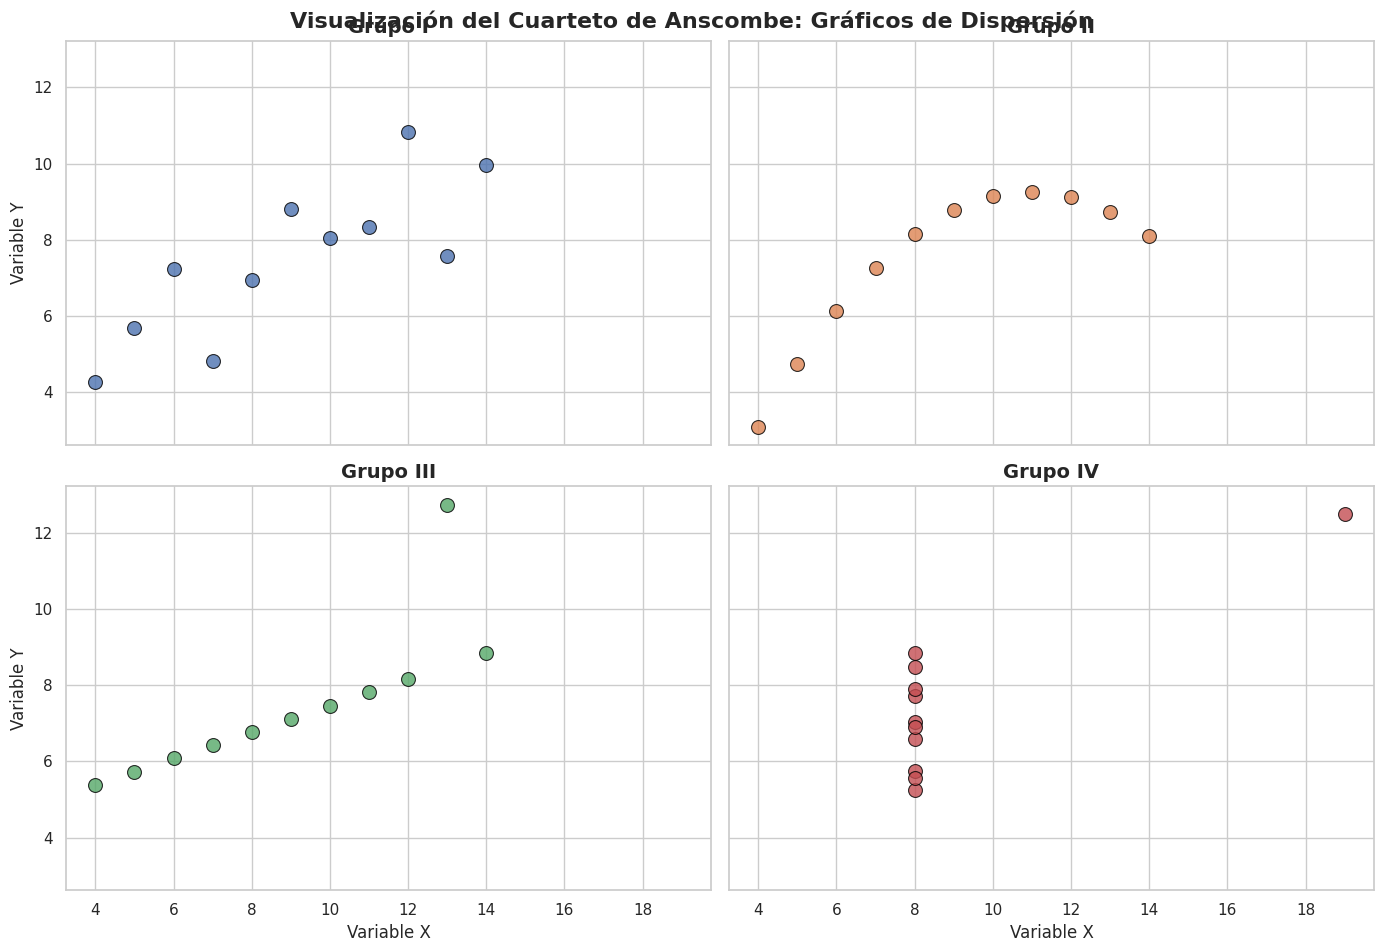

In [2]:
# FIXME
# Crear una figura con 4 subgráficos organizados en una matriz de 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Lista con los identificadores únicos de cada dataset
datasets = ['I', 'II', 'III', 'IV']
colores = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

for i, dataset_name in enumerate(datasets):
    # Filtrar datos del grupo actual
    df_sub = data[data['dataset'] == dataset_name]

    # Graficar los puntos
    sns.scatterplot(
        data=df_sub, x='x', y='y',
        ax=axes[i], color=colores[i], s=100, edgecolor='black', alpha=0.8
    )

    axes[i].set_title(f"Grupo {dataset_name}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Variable X")
    axes[i].set_ylabel("Variable Y")

plt.suptitle("Visualización del Cuarteto de Anscombe: Gráficos de Dispersión", fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [3]:
# FIXME
# Generar el resumen estadístico descriptivo agrupado por dataset para las variables x e y
print("--- Resumen Estadístico de la Variable X por Grupo ---")
print(data.groupby('dataset')['x'].describe().round(2))

print("\n--- Resumen Estadístico de la Variable Y por Grupo ---")
print(data.groupby('dataset')['y'].describe().round(2))

print("\n--- Correlación lineal (r) por Grupo ---")
for group in datasets:
    corr = data[data['dataset'] == group]['x'].corr(data[data['dataset'] == group]['y'])
    print(f"Grupo {group}: r = {corr:.3f}")

--- Resumen Estadístico de la Variable X por Grupo ---
         count  mean   std  min  25%  50%   75%   max
dataset                                              
I         11.0   9.0  3.32  4.0  6.5  9.0  11.5  14.0
II        11.0   9.0  3.32  4.0  6.5  9.0  11.5  14.0
III       11.0   9.0  3.32  4.0  6.5  9.0  11.5  14.0
IV        11.0   9.0  3.32  8.0  8.0  8.0   8.0  19.0

--- Resumen Estadístico de la Variable Y por Grupo ---
         count  mean   std   min   25%   50%   75%    max
dataset                                                  
I         11.0   7.5  2.03  4.26  6.32  7.58  8.57  10.84
II        11.0   7.5  2.03  3.10  6.70  8.14  8.95   9.26
III       11.0   7.5  2.03  5.39  6.25  7.11  7.98  12.74
IV        11.0   7.5  2.03  5.25  6.17  7.04  8.19  12.50

--- Correlación lineal (r) por Grupo ---
Grupo I: r = 0.816
Grupo II: r = 0.816
Grupo III: r = 0.816
Grupo IV: r = 0.817


3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.



Grupo I -> Intercepto: 3.00 | Pendiente: 0.50 | MSE: 1.251 | R²: 0.667
Grupo II -> Intercepto: 3.00 | Pendiente: 0.50 | MSE: 1.252 | R²: 0.666
Grupo III -> Intercepto: 3.00 | Pendiente: 0.50 | MSE: 1.251 | R²: 0.666
Grupo IV -> Intercepto: 3.00 | Pendiente: 0.50 | MSE: 1.249 | R²: 0.667


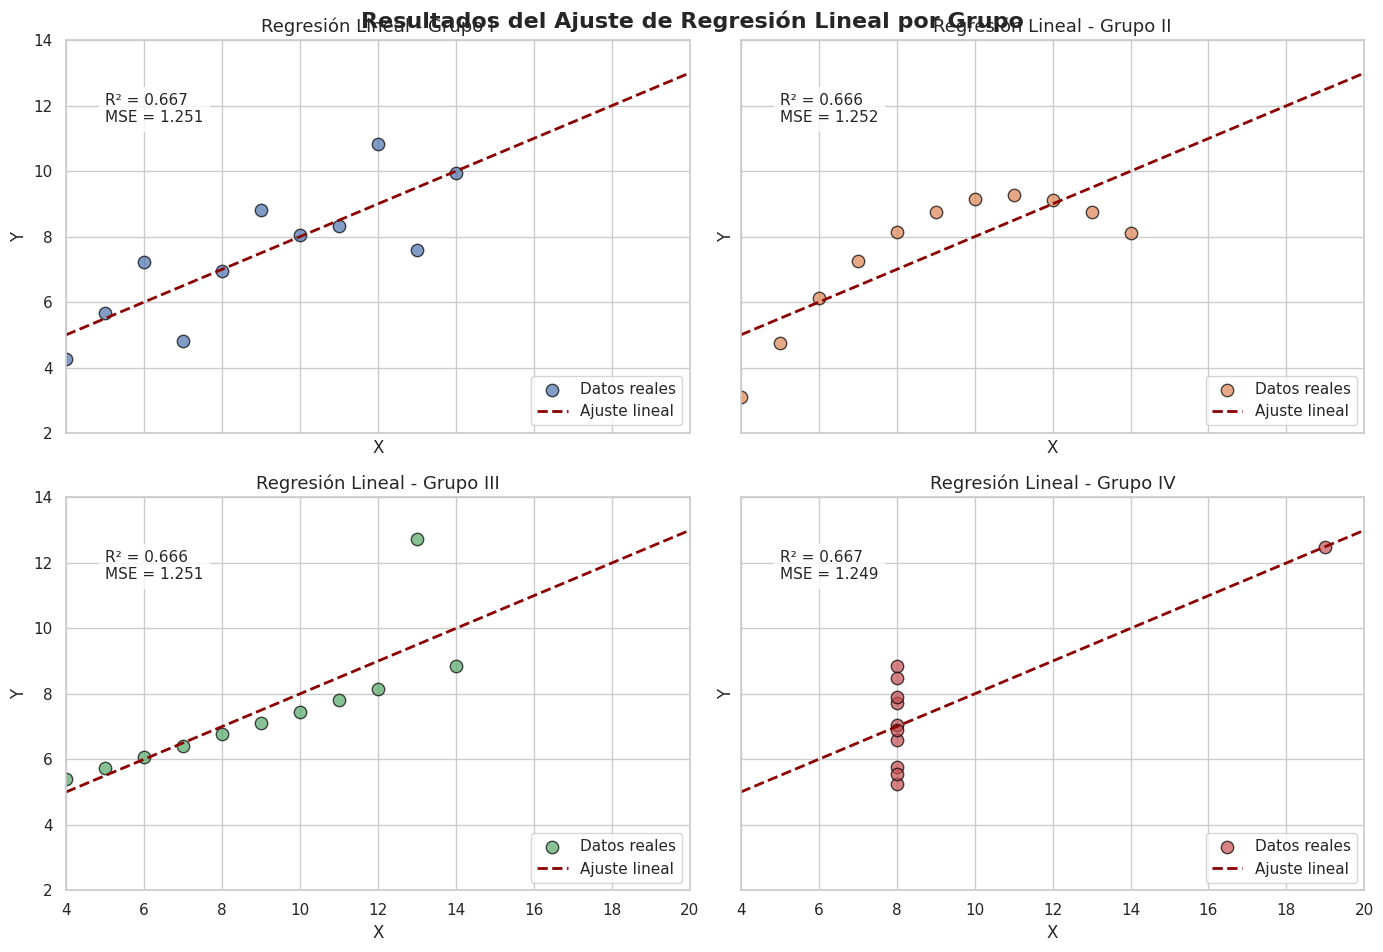

In [4]:
# FIXME
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, dataset_name in enumerate(datasets):
    # Filtrar datos por grupo
    df_sub = data[data['dataset'] == dataset_name]

    # Preparar las variables en formato de matriz para sklearn
    X = df_sub[['x']].values
    y = df_sub['y'].values

    # Instanciar y ajustar el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X, y)

    # Predecir valores para calcular métricas y graficar la recta
    y_pred = model.predict(X)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    intercept = model.intercept_
    slope = model.coef_[0]

    # Imprimir métricas en consola
    print(f"Grupo {dataset_name} -> Intercepto: {intercept:.2f} | Pendiente: {slope:.2f} | MSE: {mse:.3f} | R²: {r2:.3f}")

    # Graficar puntos reales y la línea de predicción ajustada
    axes[i].scatter(X, y, color=colores[i], s=80, edgecolor='black', label='Datos reales', alpha=0.7)

    # Crear un rango continuo para suavizar el trazo de la recta teórica
    x_range = np.linspace(4, 20, 100).reshape(-1, 1)
    y_range_pred = model.predict(x_range)
    axes[i].plot(x_range, y_range_pred, color='darkred', linestyle='--', linewidth=2, label='Ajuste lineal')

    # Añadir texto con las métricas en cada cuadrante
    axes[i].text(5, 11.5, f"R² = {r2:.3f}\nMSE = {mse:.3f}", fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
    axes[i].set_title(f"Regresión Lineal - Grupo {dataset_name}", fontsize=13)
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Y")
    axes[i].set_xlim(4, 20)
    axes[i].set_ylim(2, 14)
    axes[i].legend(loc='lower right')

plt.suptitle("Resultados del Ajuste de Regresión Lineal por Grupo", fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.

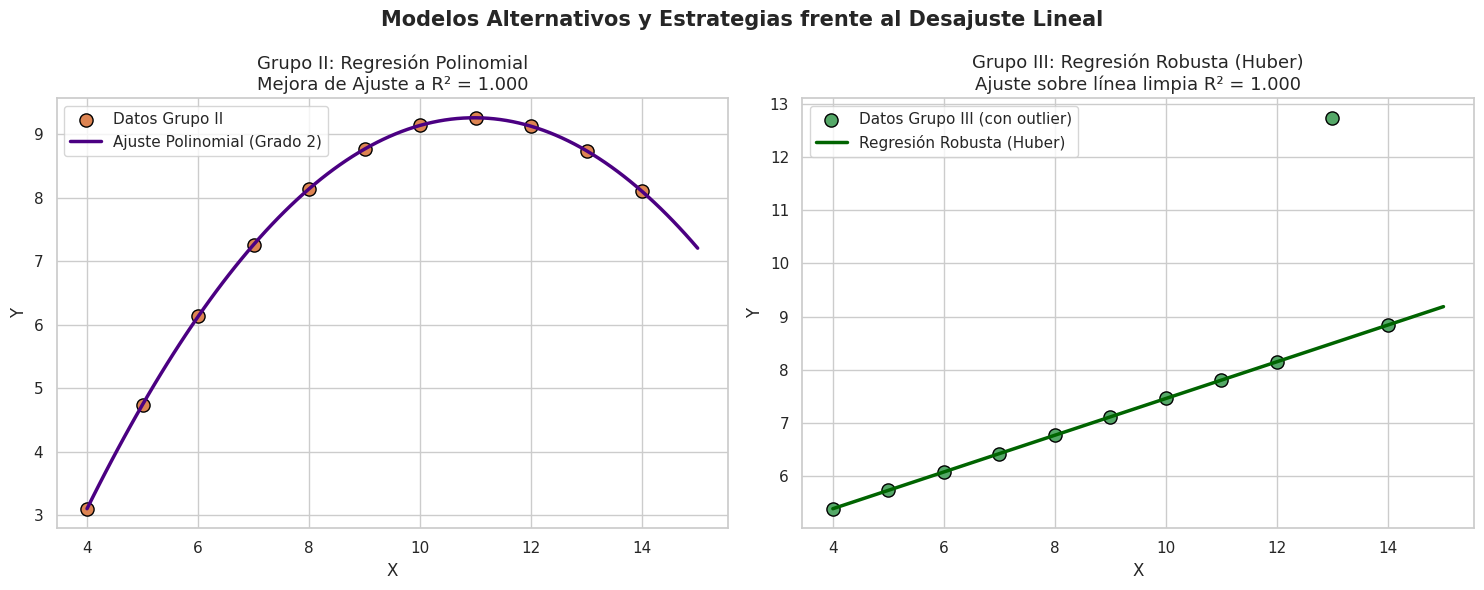

In [5]:
# FIXME
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import HuberRegressor

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# -------------------------------------------------------------
# ESTRATEGIA GRUPO II: Regresión Polinomial (Curva no lineal)
# -------------------------------------------------------------
df_ii = data[data['dataset'] == 'II']
X_ii = df_ii[['x']].values
y_ii = df_ii['y'].values

# Transformación de características a términos polinomiales de grado 2
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_ii)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_ii)

# Generar puntos de prueba continuos para graficar la parábola suavemente
x_fit = np.linspace(4, 15, 100).reshape(-1, 1)
x_fit_poly = poly.transform(x_fit)
y_fit_ii = poly_model.predict(x_fit_poly)

r2_ii_poly = r2_score(y_ii, poly_model.predict(X_poly))

ax1.scatter(X_ii, y_ii, color='#dd8452', s=90, edgecolor='black', label='Datos Grupo II')
ax1.plot(x_fit, y_fit_ii, color='indigo', linewidth=2.5, label='Ajuste Polinomial (Grado 2)')
ax1.set_title(f"Grupo II: Regresión Polinomial\nMejora de Ajuste a R² = {r2_ii_poly:.3f}", fontsize=13)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.legend()


# -------------------------------------------------------------
# ESTRATEGIA GRUPO III: Regresión Robusta (Manejo de Outliers)
# -------------------------------------------------------------
df_iii = data[data['dataset'] == 'III']
X_iii = df_iii[['x']].values
y_iii = df_iii['y'].values

# El HuberRegressor disminuye la influencia de las muestras atípicas (outliers)
huber = HuberRegressor(epsilon=1.35)
huber.fit(X_iii, y_iii)

x_fit_iii = np.linspace(4, 15, 100).reshape(-1, 1)
y_fit_iii = huber.predict(x_fit_iii)

# Calculamos R² excluyendo el outlier para demostrar cómo se adhiere a la línea principal limpia
# El outlier en el Grupo III está en x=13, y=12.74
clean_mask = y_iii < 12
r2_iii_huber_clean = r2_score(y_iii[clean_mask], huber.predict(X_iii[clean_mask]))

ax2.scatter(X_iii, y_iii, color='#55a868', s=90, edgecolor='black', label='Datos Grupo III (con outlier)')
ax2.plot(x_fit_iii, y_fit_iii, color='darkgreen', linewidth=2.5, label='Regresión Robusta (Huber)')
ax2.set_title(f"Grupo III: Regresión Robusta (Huber)\nAjuste sobre línea limpia R² = {r2_iii_huber_clean:.3f}", fontsize=13)
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.legend()

plt.suptitle("Modelos Alternativos y Estrategias frente al Desajuste Lineal", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()